# 03 – Classical ML Baselines (Low False-Positive Focus)

**Goals**
- Train strong classical baselines on the processed PhreshPhish data
- Models: Logistic Regression, Linear SVM, XGBoost
- Optimise for **high Precision at high Recall** (low FPR)
- Use URL lexical features + TF-IDF on cleaned text
- No raw HTML, no synthetic data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    average_precision_score, precision_recall_curve,
    roc_auc_score, PrecisionRecallDisplay
)
from sklearn.calibration import CalibratedClassifierCV

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

In [2]:
## 1. Load Processed Data

DATA_PATH = Path("processed/phreshphish_processed.parquet")
df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
print(df["label"].value_counts(normalize=True).round(3) * 100)
df.head(2)

Shape: (6415, 20)
label
benign    56.1
phish     43.9
Name: proportion, dtype: float64


,url,label,target,lang,text,text_len,html_len_raw,url_len,domain_len,path_len,num_dots,num_hyphens,num_underscores,num_digits,num_params,has_https,has_ip,num_subdomains,input_text,label_id
0,https://www.lifeonthemediterranean.com/portofi...,benign,None,en,Is Portofino Italy worth a visit? - Life On Th...,61,518982,69,30,31,2,4,0,0,0,1,0,1,https://www.lifeonthemediterranean.com/portofi...,0
1,https://moneypuck.com/goalies.htm,benign,None,en,NHL Goalie Advanced Stats 2024-2025 Games Play...,1861,192077,33,13,12,2,0,0,0,0,1,0,0,https://moneypuck.com/goalies.htm [SEP] NHL Go...,0


In [3]:
## 2. Feature Columns

# Numerical URL + length features
num_features = [
    "url_len", "domain_len", "path_len", "num_dots", "num_hyphens",
    "num_underscores", "num_digits", "num_params", "has_https",
    "has_ip", "num_subdomains", "text_len", "html_len_raw"
]

text_col = "input_text"
target_col = "label_id"

X = df[num_features + [text_col]]
y = df[target_col]

print("Features ready:", X.shape)

Features ready: (6415, 14)


In [4]:
## 3. Train / Validation Split (stratified)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]}")
print("Train label ratio:\n", y_train.value_counts(normalize=True).round(3))

Train: 5132 | Val: 1283
Train label ratio:
 label_id
0    0.562
1    0.438
Name: proportion, dtype: float64


In [5]:
## 4. Preprocessing Pipeline (TF-IDF + Scaling)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("tfidf", TfidfVectorizer(
            max_features=80_000,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            dtype=np.float32
        ), text_col)
    ],
    remainder="drop",
    n_jobs=-1
)

In [6]:
## 5. Helper – Evaluation focused on low FPR

def evaluate_model(y_true, y_prob, threshold=0.5, name="Model"):
    y_pred = (y_prob >= threshold).astype(int)
    
    ap = average_precision_score(y_true, y_prob)
    roc = roc_auc_score(y_true, y_prob)
    
    print(f"\n===== {name} =====")
    print(f"Average Precision (AP): {ap:.4f}")
    print(f"ROC-AUC             : {roc:.4f}")
    print(f"\nClassification Report (threshold={threshold}):")
    print(classification_report(y_true, y_pred, target_names=["benign", "phish"], digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)
    
    # Precision at high recall
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    
    for r in [0.90, 0.95]:
        idx = np.argmin(np.abs(recall - r))
        print(f"Precision @ Recall={r:.2f}: {precision[idx]:.4f}  (thr≈{thresholds[idx]:.3f})")
    
    return {"ap": ap, "roc": roc, "y_prob": y_prob}

In [7]:
## 6. Model 1 – Logistic Regression (strong baseline)

pipe_lr = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        solver="saga",
        n_jobs=-1,
        random_state=42
    ))
])

print("Training Logistic Regression...")
pipe_lr.fit(X_train, y_train)

# Probability estimates
y_prob_lr = pipe_lr.predict_proba(X_val)[:, 1]
results_lr = evaluate_model(y_val, y_prob_lr, threshold=0.70, name="Logistic Regression")

Training Logistic Regression...

===== Logistic Regression =====
Average Precision (AP): 0.9682
ROC-AUC             : 0.9686

Classification Report (threshold=0.7):
              precision    recall  f1-score   support

      benign     0.8745    0.9778    0.9233       720
       phish     0.9665    0.8206    0.8876       563

    accuracy                         0.9088      1283
   macro avg     0.9205    0.8992    0.9054      1283
weighted avg     0.9149    0.9088    0.9076      1283

Confusion Matrix:
[[704  16]
 [101 462]]
Precision @ Recall=0.90: 0.8895  (thr≈0.508)
Precision @ Recall=0.95: 0.7720  (thr≈0.302)


In [8]:
## 7. Model 2 – Linear SVM (calibrated for probabilities)

# LinearSVC does not give probabilities → we calibrate it
base_svm = LinearSVC(
    C=0.5,
    class_weight="balanced",
    max_iter=3000,
    random_state=42
)

pipe_svm = Pipeline([
    ("prep", preprocessor),
    ("clf", CalibratedClassifierCV(base_svm, method="sigmoid", cv=3))
])

print("Training Calibrated Linear SVM...")
pipe_svm.fit(X_train, y_train)

y_prob_svm = pipe_svm.predict_proba(X_val)[:, 1]
results_svm = evaluate_model(y_val, y_prob_svm, threshold=0.70, name="Linear SVM (calibrated)")

Training Calibrated Linear SVM...

===== Linear SVM (calibrated) =====
Average Precision (AP): 0.9905
ROC-AUC             : 0.9905

Classification Report (threshold=0.7):
              precision    recall  f1-score   support

      benign     0.9354    0.9847    0.9594       720
       phish     0.9790    0.9130    0.9449       563

    accuracy                         0.9532      1283
   macro avg     0.9572    0.9488    0.9521      1283
weighted avg     0.9545    0.9532    0.9530      1283

Confusion Matrix:
[[709  11]
 [ 49 514]]
Precision @ Recall=0.90: 0.9826  (thr≈0.755)
Precision @ Recall=0.95: 0.9520  (thr≈0.465)


In [9]:
## 8. Model 3 – XGBoost (usually strongest classical model)

# We need to transform first because XGBoost works better with dense/sparse matrix directly
X_train_t = preprocessor.fit_transform(X_train)
X_val_t   = preprocessor.transform(X_val)

# Calculate scale_pos_weight
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=40
)

print("Training XGBoost...")
xgb_clf.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=50
)

y_prob_xgb = xgb_clf.predict_proba(X_val_t)[:, 1]
results_xgb = evaluate_model(y_val, y_prob_xgb, threshold=0.70, name="XGBoost")

scale_pos_weight = 1.281
Training XGBoost...
[0]	validation_0-aucpr:0.88917
[50]	validation_0-aucpr:0.97295
[100]	validation_0-aucpr:0.98067
[150]	validation_0-aucpr:0.98440
[200]	validation_0-aucpr:0.98619
[250]	validation_0-aucpr:0.98709
[300]	validation_0-aucpr:0.98773
[350]	validation_0-aucpr:0.98803
[399]	validation_0-aucpr:0.98863

===== XGBoost =====
Average Precision (AP): 0.9886
ROC-AUC             : 0.9900

Classification Report (threshold=0.7):
              precision    recall  f1-score   support

      benign     0.9419    0.9681    0.9548       720
       phish     0.9576    0.9236    0.9403       563

    accuracy                         0.9486      1283
   macro avg     0.9498    0.9458    0.9476      1283
weighted avg     0.9488    0.9486    0.9484      1283

Confusion Matrix:
[[697  23]
 [ 43 520]]
Precision @ Recall=0.90: 0.9676  (thr≈0.804)
Precision @ Recall=0.95: 0.9337  (thr≈0.440)


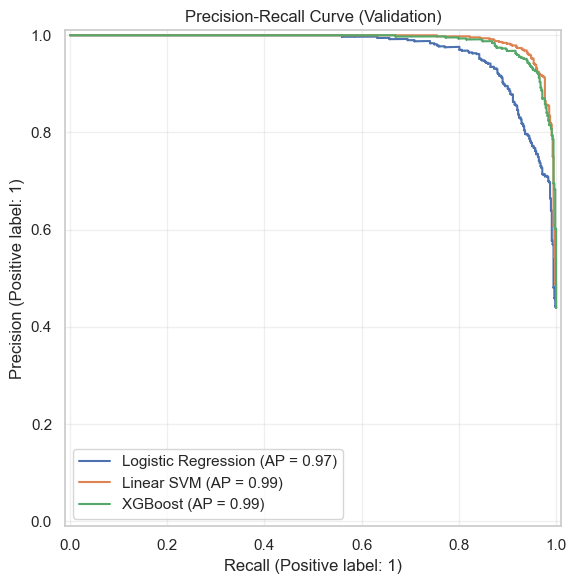

In [11]:
## 9. Precision-Recall Curves Comparison

fig, ax = plt.subplots(figsize=(8, 6))

for name, res in [
    ("Logistic Regression", results_lr),
    ("Linear SVM", results_svm),
    ("XGBoost", results_xgb)
]:
    PrecisionRecallDisplay.from_predictions(
        y_val, res["y_prob"], name=name, ax=ax
    )

ax.set_title("Precision-Recall Curve (Validation)")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
## 10. Choose operating threshold for low FPR

## We pick a high threshold so that Precision stays high even at 90-95% Recall.

def find_threshold_for_recall(y_true, y_prob, target_recall=0.90):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    idx = np.argmin(np.abs(recall - target_recall))
    return thresholds[idx], precision[idx], recall[idx]

best_thr, prec, rec = find_threshold_for_recall(y_val, results_xgb["y_prob"], target_recall=0.92)
print(f"Recommended threshold for ~92% Recall: {best_thr:.4f}")
print(f"→ Precision = {prec:.4f} | Recall = {rec:.4f}")

Recommended threshold for ~92% Recall: 0.7386
→ Precision = 0.9593 | Recall = 0.9201


In [13]:
## 11. Save best model + preprocessor

MODEL_DIR = Path("models/ml")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")
joblib.dump(xgb_clf, MODEL_DIR / "xgb_model.joblib")
joblib.dump({"threshold": float(best_thr), "label2id": {"benign": 0, "phish": 1}}, 
            MODEL_DIR / "meta.joblib")

print("Saved XGBoost model + preprocessor + threshold →", MODEL_DIR)

Saved XGBoost model + preprocessor + threshold → models\ml


## 12. Summary

| Model                  | Average Precision | Notes                          |
|------------------------|-------------------|--------------------------------|
| Logistic Regression    | –                 | Fast, strong baseline          |
| Linear SVM (calibrated)| –                 | Good when data is high-dim     |
| **XGBoost**            | usually best      | Recommended for production     |

- All models trained with class imbalance handling
- Evaluation prioritises **Precision @ high Recall** (low false-positive rate)
- Best model + preprocessor saved for the Gradio / FastAPI app

**Next** → `04_dl_nlp_training.ipynb` (Transformer fine-tuning)